In [1]:
# selected predictors
import pickle
from config import use_model
with open('5_selection_meta.pkl', 'rb') as f:
    selection_meta = pickle.load(f)

rows = []
for var in use_model:
    for fold in range(10):
        row = {
            'Variable': var,
            'model': use_model[var],
            'fold': fold,
        }
        selected = selection_meta[(selection_meta['var'] == var) & (selection_meta['fold'] == fold) & (selection_meta['model'] == use_model[var])]['selected_predictors'].values[0]
        for n, predictor in enumerate(selected):
            row[n] = predictor
        rows.append(row)
import pandas as pd




# More general and robust replacement for grouped predictors
import numpy as np

# Build mapping: each detailed predictor pattern maps to a standard name, e.g. "N_2018" -> "N"
group_map = {}

LUCAS_vars = ['doy', 'N', 'P', 'pH_c', 'OC', 'pH', 'CaCO3_c', 'K', 'Calc']
for var in LUCAS_vars:
    group_map[f"{var}_avg_09_15_18"] = var
    for year in [2009, 2015, 2018]:
        group_map[f"{var}_{year}"] = var

for year in [2009, 2015, 2018]:
    group_map[f"MODIS_NPP_{year}gps_{year}"] = 'NPP'
    group_map[f"MODIS_NPP_{year}gps_{year-1}"] = 'NPP-1'
    group_map[f"MODIS_NPP_{year}gps_{year-2}"] = 'NPP-2'

for i in range(1, 20):
    for year in [2009, 2015, 2018]:
        group_map[f"BIOCLIM_{year}gps_{i}"] = f"BioClim {i}"

for year in [2009, 2015, 2018]:
    for letter in ['D', 'E', 'C', 'H']:
        group_map[f"lc1_2_{year}_{letter}"] = letter
    
for year in [2009, 2015, 2018]:
    for letter in ['D20', 'H12', 'nan']:
        group_map[f"lc1_{year}_{letter}"] = letter

for soil_g in ['Albeluvisols', 'Planosols', 'Podzols', 'Histosols', 'Cambisols']:
    group_map[f"Soil_Group_{soil_g}"] = soil_g

for i in range(64):
    for prefix in ["2018gps", "2009gps", "2015gps"]:
        for year in [2017, 2015, 2018]:
            group_map[f"AE{i:02d}_{prefix}_{year}"] = f"AE{i:02d}"

group_map["Ox_Fe_2018"] = "Ox_Fe"
group_map["Ox_Al_2018"] = "Ox_Al"
for year in [2009, 2015, 2018]:
    group_map[f"HALA_{year}gps_topsoil"] = "HALA"

group_map["LC_change_09_15_18_F_E_B"] = "F E B" 
group_map["MODIS_NPP_2015gps_2011"] = "NPP 2011" 
group_map["MODIS_NPP_2015gps_2010"] = "NPP 2010" 

# Flatten df to replace in all cells except for identifier columns
df = pd.DataFrame(rows)
df.to_csv("figures/selected_predictors_raw.csv", index=False)

identifier_cols = ['Variable', 'model', 'fold']
predictor_cols = [col for col in df.columns if col not in identifier_cols]

def replace_predictor(val):
    if pd.isnull(val):
        return val
    return group_map.get(val, val)

# Apply column-wise using .apply() + map (since DataFrame has no .applymap() for this type of column selection)
for col in predictor_cols:
    df[col] = df[col].map(replace_predictor)

df.to_csv("figures/selected_predictors.csv", index=False)

df

,Variable,model,fold,0,1,2,3,4,5,6,...,10,11,12,13,14,15,16,17,18,19
0,BD,LinReg,0,OC,AE15,pH,N,AE61,AE01,doy,...,Calc,Sand,AE02,AE36,AE29,AE60,BioClim 15,AE38,AE05,AE51
1,BD,LinReg,1,OC,AE04,AE55,AE09,CaCO3_c,AE12,BioClim 4,...,AE54,AE32,AE50,AE06,AE51,AE61,AE40,AE36,AE62,AE31
2,BD,LinReg,2,OC,AE20,AE07,doy,AE35,BioClim 18,BioClim 13,...,Coarse,AE12,Calc,Ox_Fe,AE03,AE03,AE21,AE50,AE44,AE61
3,BD,LinReg,3,OC,pH,AE07,AE32,doy,AE29,BioClim 19,...,AE11,AE05,Coarse,AE00,BioClim 15,AE40,AE43,AE51,AE16,BioClim 13
4,BD,LinReg,4,OC,AE15,AE61,AE01,AE07,N,doy,...,AE10,AE21,BioClim 19,BioClim 3,AE05,BioClim 10,AE61,AE04,AE53,AE14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,SOC18,XGB,5,N,pH,AE23,AE10,AE44,E,AE11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
76,SOC18,XGB,6,N,pH,BioClim 1,AE07,AE31,AE36,BioClim 4,...,BioClim 17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,SOC18,XGB,7,N,pH,AE61,AE58,pH_c,H12,BioClim 3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,SOC18,XGB,8,N,pH,BioClim 6,AE08,BioClim 19,AE52,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# load TARGET_CONGIG -> possible predictors per task
from config import TARGET_CONFIG, pred_groups, TRAIN_DEFAULTS
# columns: variable, year, possible predictor groups
# rows: trainings + inferences

rows = []
for var in TARGET_CONFIG:
    possible_groups = TARGET_CONFIG[var]['categoricals']
    single_preds = TARGET_CONFIG[var]['predictors'] + TARGET_CONFIG[var]['log_predictors']
    for i in pred_groups:
        if isinstance(pred_groups[i], dict):
            for j in pred_groups[i]:
                if all(item in single_preds for item in pred_groups[i][j]):
                    possible_groups.append((i, j))
        else:
            if all(item in single_preds for item in pred_groups[i]):
                possible_groups.append((i))
    if len(TARGET_CONFIG[var]["inference"]) > 1:
        year = TARGET_CONFIG[var]["target_name"][-4:]
    else:
        year = '-'
    possible_groups = list(dict.fromkeys(possible_groups))
    rows.append({
        'Variable': var, 
        'Year': year, 
        'Action': 'train & infer', 
        'Predictor Groups': possible_groups
        })
    if len(TARGET_CONFIG[var]["inference"]) > 1:
        for infer in TARGET_CONFIG[var]["inference"]:
            if infer['target_name'][-4:] != year:
                possible_groups = infer['categoricals']
                single_preds = infer['predictors'] + infer['log_predictors']
                for i in pred_groups:
                    if isinstance(pred_groups[i], dict):
                        for j in pred_groups[i]:
                            if all(item in single_preds for item in pred_groups[i][j]):
                                possible_groups.append((i, j))
                    else:
                        if all(item in single_preds for item in pred_groups[i]):
                            possible_groups.append((i))
                possible_groups = list(dict.fromkeys(possible_groups))
                rows.append({
                    'Variable': var, 
                    'Year': infer['target_name'][-4:], 
                    'Action': 'only infer', 
                    'Predictor Groups': possible_groups
                    })
import pandas as pd

# Find all unique predictor group names across all rows, in order of first appearance
group_names = []
for row in rows:
    for group in row['Predictor Groups']:
        group_label = group[0] if isinstance(group, tuple) else group
        if group_label not in group_names:
            group_names.append(group_label)

# Prepare data for DataFrame
data = []
for row in rows:
    row_data = {
        'Variable': row['Variable'],
        'Year': row['Year'],
        'Action': row['Action']
    }
    # Initialize all groups as None
    for group_label in group_names:
        row_data[group_label] = None
    # Fill in the appropriate values
    for group in row['Predictor Groups']:
        if isinstance(group, tuple):
            # (group_label, year)
            group_label, year = group
            row_data[group_label] = str(year)
        else:
            # constant group (no year)
            row_data[group] = 'constant'
    data.append(row_data)
df = pd.DataFrame(data)
df.to_csv("figures/predictor_groups.csv", index=False)
df

,Variable,Year,Action,Texture,Mineral Activity,Ox. ex. Al/Fe,MODIS NPP 20xx-2a,AlphaEarth 2017+2018,WorldClim,LUCAS normal,...,lc1_2_2015,lc1_2015,lc1_2_2018,lc1_2018,change,LC_change_09_15_18,MODIS NPP 09-18,LUCAS normal avg,LUCAS log avg,OC (log) avg
0,BD,2018,train & infer,constant,2018,constant,2018,2018,2018,2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BD,2015,only infer,constant,2015,constant,2015,2015,2015,2015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BD,2009,only infer,constant,2009,constant,2009,2009,2009,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MAOC,2009,train & infer,constant,2009,constant,2009,2009,2009,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MAOC,2015,only infer,constant,2015,constant,2015,2015,2015,2015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,MAOC,2018,only infer,constant,2018,constant,2018,2018,2018,2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,MIC,2018,train & infer,constant,2018,constant,2018,2018,2018,2018,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,MIC,2015,only infer,constant,2015,constant,2015,2015,2015,2015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,MIC,2009,only infer,constant,2009,constant,2009,2009,2009,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,SOC09,2009,train & infer,constant,2009,constant,2009,2009,2009,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


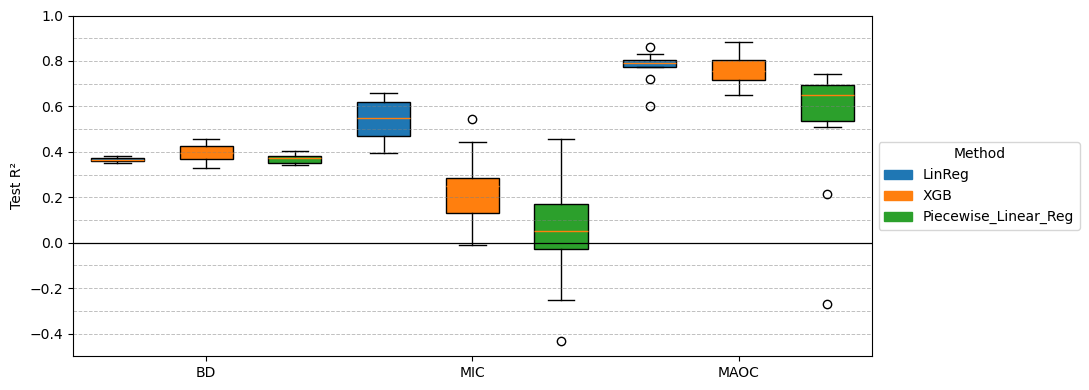

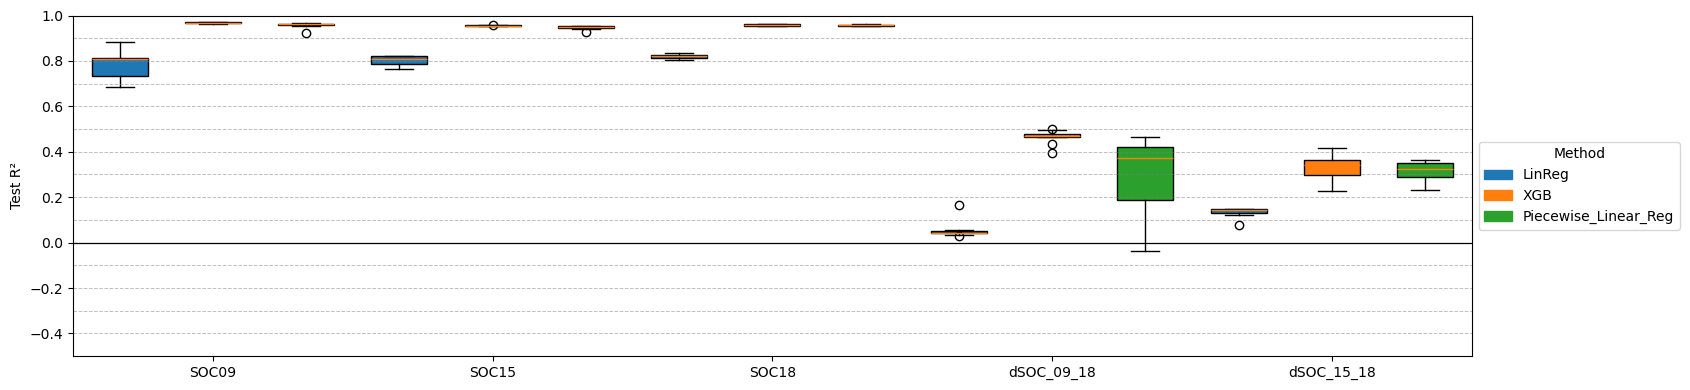

In [3]:
# load 5_with_predictions.pkl -> boxplots, transferability plots
import pickle
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load the predictions DataFrame from '5_with_predictions.pkl'
with open('5_with_predictions.pkl', 'rb') as f:
    pred_df = pickle.load(f)

def boxplot(plot_vars):
    fig, ax = plt.subplots(figsize=(len(plot_vars)*3+2, 4))
    for var in plot_vars:
        for method in TRAIN_DEFAULTS['models']:
            cols = [f'pred_{var}_fold{f}_{method}' for f in range(10)]
            mask = (pred_df['split'] == 'test') & (~pred_df[TARGET_CONFIG[var]['target_name']].isna())
            preds = pred_df.loc[mask, cols]
            target = pred_df.loc[mask, TARGET_CONFIG[var]['target_name']]
            r2s = [r2_score(target, preds[col]) for col in cols]
            ax.boxplot(
                r2s,
                positions=[plot_vars.index(var)*len(TRAIN_DEFAULTS['models']) + TRAIN_DEFAULTS['models'].index(method)],
                widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor='C{}'.format(TRAIN_DEFAULTS['models'].index(method))))

    ax.set_xticks([i * len(TRAIN_DEFAULTS['models']) + len(TRAIN_DEFAULTS['models'])/2 - 0.5 for i in range(len(plot_vars))])
    ax.set_xticklabels(plot_vars)
    ax.set_ylim(-0.5, 1.0)
    ax.set_ylabel('Test R²')

    y = -0.5
    while y <= 1.001:
        if abs(y - 0.0) < 1e-8:
            ax.axhline(y=0.0, color='black', linestyle='-', linewidth=0.9, alpha=1.0)
        else:
            ax.axhline(y=y, color='gray', linestyle='dashed', linewidth=0.7, alpha=0.5)
        y = round(y + 0.1, 10)

    method_colors = [f'C{i}' for i in range(len(TRAIN_DEFAULTS['models']))]
    handles = [mpatches.Patch(color=method_colors[i], label=method) for i, method in enumerate(TRAIN_DEFAULTS['models'])]
    ax.legend(handles=handles, title='Method', loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
    plt.tight_layout()
    plt.savefig(f'figures/boxplot_{"_".join(plot_vars)}.png', dpi=150)

boxplot(['BD', 'MIC', 'MAOC'])
boxplot(['SOC09', 'SOC15', 'SOC18', 'dSOC_09_18', 'dSOC_15_18'])

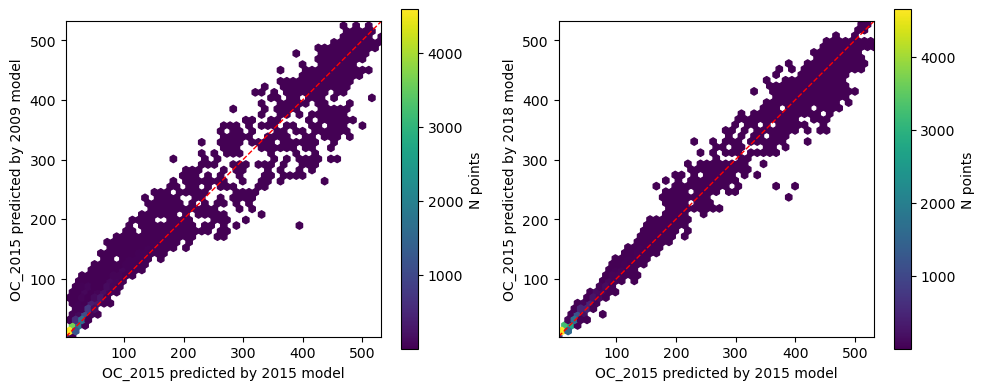

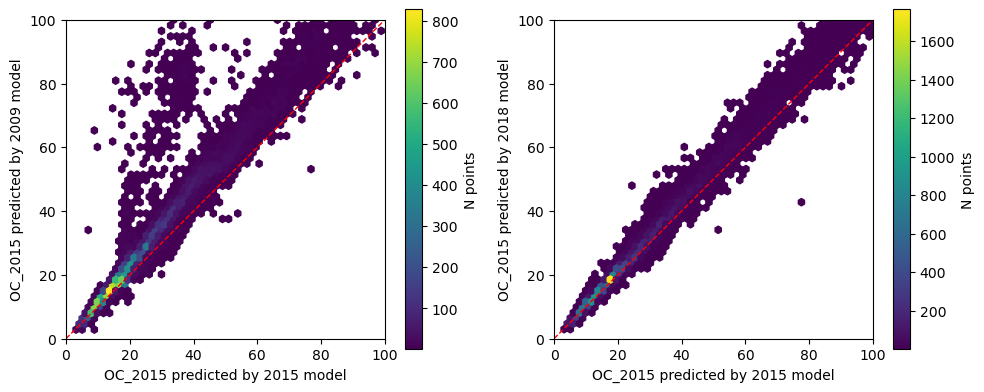

In [4]:
# Save the figure produced in addition to showing it
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

results = pd.read_pickle("5_with_predictions.pkl")
results.columns.values
OC_15_pred_with_15_model = results["pred_SOC15_median_XGB_inf_OC_2015"]
OC_15_pred_with_09_model = results["pred_SOC09_median_XGB_inf_OC_2015"]
OC_15_pred_with_18_model = results["pred_SOC18_median_XGB_inf_OC_2015"]

def plot_oc_compare_hexbin(
    OC_15_pred_with_15_model, OC_15_pred_with_09_model, OC_15_pred_with_18_model, 
    max_lim=None, save_name_suffix=""
):
    import matplotlib.pyplot as plt
    import numpy as np

    # Optionally filter points to be inside [0, max_lim] for both x and y in each subplot
    x1, y1 = OC_15_pred_with_15_model, OC_15_pred_with_09_model
    x2, y2 = OC_15_pred_with_15_model, OC_15_pred_with_18_model
    if max_lim is not None:
        mask1 = (x1 >= 0) & (x1 <= max_lim) & (y1 >= 0) & (y1 <= max_lim)
        mask2 = (x2 >= 0) & (x2 <= max_lim) & (y2 >= 0) & (y2 <= max_lim)
        x1, y1 = x1[mask1], y1[mask1]
        x2, y2 = x2[mask2], y2[mask2]
        lims_15_09 = [0, max_lim]
        lims_15_18 = [0, max_lim]
    else:
        lims_15_09 = [
            min(OC_15_pred_with_15_model.min(), OC_15_pred_with_09_model.min()),
            max(OC_15_pred_with_15_model.max(), OC_15_pred_with_09_model.max()),
        ]
        lims_15_18 = [
            min(OC_15_pred_with_15_model.min(), OC_15_pred_with_18_model.min()),
            max(OC_15_pred_with_15_model.max(), OC_15_pred_with_18_model.max()),
        ]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Hexbin 1: 2015 model vs 2009 model
    hb1 = axs[0].hexbin(
        x1, y1, gridsize=50, cmap="viridis", mincnt=1
    )
    axs[0].plot(lims_15_09, lims_15_09, "r--", lw=1)
    axs[0].set_xlim(lims_15_09)
    axs[0].set_ylim(lims_15_09)
    axs[0].set_aspect("equal", "box")
    axs[0].set_xlabel("OC_2015 predicted by 2015 model")
    axs[0].set_ylabel("OC_2015 predicted by 2009 model")
    cb1 = fig.colorbar(hb1, ax=axs[0], label='N points')

    # Hexbin 2: 2015 model vs 2018 model
    hb2 = axs[1].hexbin(
        x2, y2, gridsize=50, cmap="viridis", mincnt=1
    )
    axs[1].plot(lims_15_18, lims_15_18, "r--", lw=1)
    axs[1].set_xlim(lims_15_18)
    axs[1].set_ylim(lims_15_18)
    axs[1].set_aspect("equal", "box")
    axs[1].set_xlabel("OC_2015 predicted by 2015 model")
    axs[1].set_ylabel("OC_2015 predicted by 2018 model")
    cb2 = fig.colorbar(hb2, ax=axs[1], label='N points')

    plt.tight_layout()
    save_name = "figures/oc_compare_hexbin"
    if save_name_suffix:
        save_name += f"_{save_name_suffix}"
    save_name += ".png"
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

# Plot without fixed max limit (default behavior, like before)
plot_oc_compare_hexbin(OC_15_pred_with_15_model, OC_15_pred_with_09_model, OC_15_pred_with_18_model)

# Plot with fixed max limit of 100 for both axes
plot_oc_compare_hexbin(
    OC_15_pred_with_15_model,
    OC_15_pred_with_09_model,
    OC_15_pred_with_18_model,
    max_lim=100,
    save_name_suffix="max100"
)

In [3]:
from config import default_param_ranges, default_state_bounds

import pandas as pd

translate = {
    "Cp": "POC",
    "Cb": "MIC",
    "Cm": "MAOC"
}

# Make table for default_param_ranges
param_rows = []
for p, vals in default_param_ranges.items():
    row = {
        "Parameter/State variable": p,
        "Description": vals["description"],
        "Min": vals["min"],
        "Craig's Default": vals["default"],
        "Max": vals["max"],
        "Unit": vals["unit"]
    }
    param_rows.append(row)
df_params = pd.DataFrame(param_rows)

# Make table for default_state_bounds
state_rows = []
for s, vals in default_state_bounds.items():
    row = {
        "Parameter/State variable": translate[s],
        "Description": vals["description"],
        "Min": vals["min"],
        "Craig's Default": vals["default"],
        "Max": vals["max"],
        "Unit": vals.get("unit", "")
    }
    state_rows.append(row)
df_states = pd.DataFrame(state_rows)

df_all = pd.concat([df_params, df_states], ignore_index=True)
print("Default Parameter Ranges and State Bounds (concatenated):")
display(df_all)
df_all.to_csv("figures/default_param_ranges_and_state_bounds.csv", index=False)

Default Parameter Ranges and State Bounds (concatenated):


,Parameter/State variable,Description,Min,Craig's Default,Max,Unit
0,I,Carbon input rate (enters particulate SOC pool),0.065000,1.82,2.6,mg C cm^-3 soil yr^-1
1,CUE,Microbial carbon use efficiency,0.100000,0.47,0.8,-
2,beta,Density‑dependence exponent for microbial turn...,0.500000,1.0,2.5,-
3,tmb,Proportion of microbial turnover transferred t...,0.100000,-,1.0,-
4,Cg0b,Microbial biomass at which microbial growth ra...,0.000650,2.6,13.0,mg C cm^-3 soil
5,Cg0m,Mineral‑associated SOC pool size at which grow...,0.650000,35.1,195.0,mg C cm^-3 soil
6,qx,Dimensionless scaling factor (not used in the ...,0.100000,1.0,10.0,-
7,Vmax_p,Maximum decomposition rate for particulate SOC,8.800000,88.0,880.0,yr^-1
8,Vmax_m,Maximum decomposition rate for mineral‑associa...,17.100000,171.0,1710.0,yr^-1
9,Km_p,Half‑saturation constant for particulate SOC d...,18.720000,144.0,1872.0,mg C cm^-3 soil
